In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
file_path = r'/content/preprocessed_demand_data (1) (1).csv'

df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

In [3]:
target = 'OrderCount'

# 'NumberOfPieces' and 'TotalRevenue' excluded -> data leakage risk
features = [
    'Holiday_Indicator_Encoded',
    'Festival_Name_Encoded',
    'Season_Encoded',
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
    'WeekOfYear',
    'IsWeekend',
    'Quarter',
    'OrderCount_lag_1',
    'OrderCount_lag_7',
    'OrderCount_lag_14',
    'OrderCount_rolling_mean_7',
    'OrderCount_rolling_std_7'
]

categorical_features = ['Hub', 'Region']

for col in categorical_features:
    df[col] = df[col].astype('category')

all_features = features + categorical_features

X = df[all_features]
y = df[target]

In [4]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [5]:
train_data = lgb.Dataset(
    X_train, label=y_train, categorical_feature=categorical_features
)
test_data = lgb.Dataset(
    X_test, label=y_test, reference=train_data, categorical_feature=categorical_features
)

In [6]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

In [7]:
print("Training LightGBM model...")

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 41.7139	valid_1's rmse: 63.4571
Early stopping, best iteration is:
[140]	training's rmse: 39.1219	valid_1's rmse: 63.1037


In [8]:
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")


--- Model Evaluation ---
RMSE: 63.1037
MAE: 42.8729
R2 Score: 0.9088


In [9]:
importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Important Features ---")
print(importance.head(5))


--- Top 5 Important Features ---
                      Feature    Importance
6                   DayOfWeek  1.139329e+09
11           OrderCount_lag_7  4.758251e+08
13  OrderCount_rolling_mean_7  4.061846e+08
12          OrderCount_lag_14  8.379967e+07
8                   IsWeekend  7.576423e+07


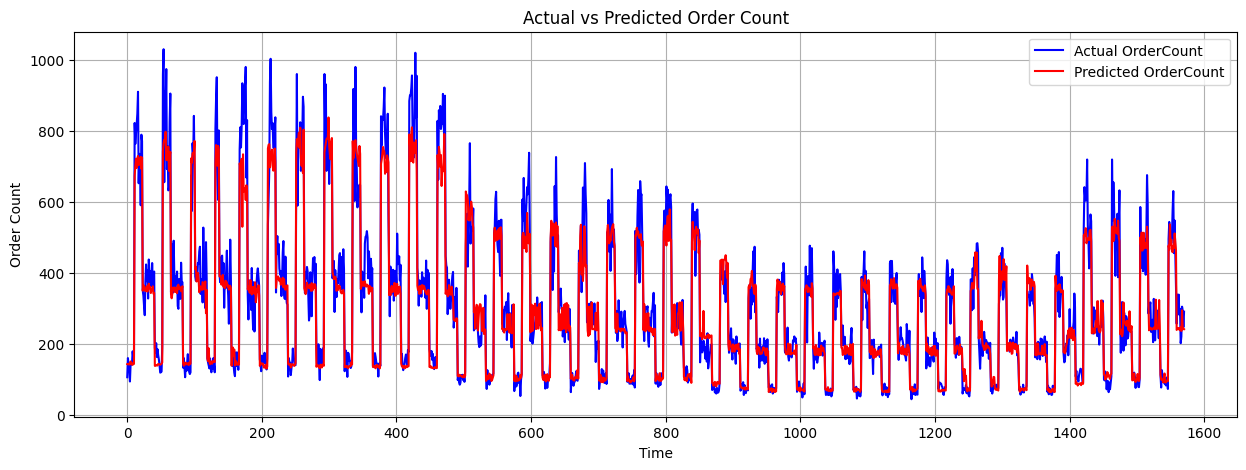

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.values, label="Actual OrderCount", color="blue")
plt.plot(y_pred, label="Predicted OrderCount", color="red")
plt.title("Actual vs Predicted Order Count")
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.legend()
plt.grid()
plt.show()

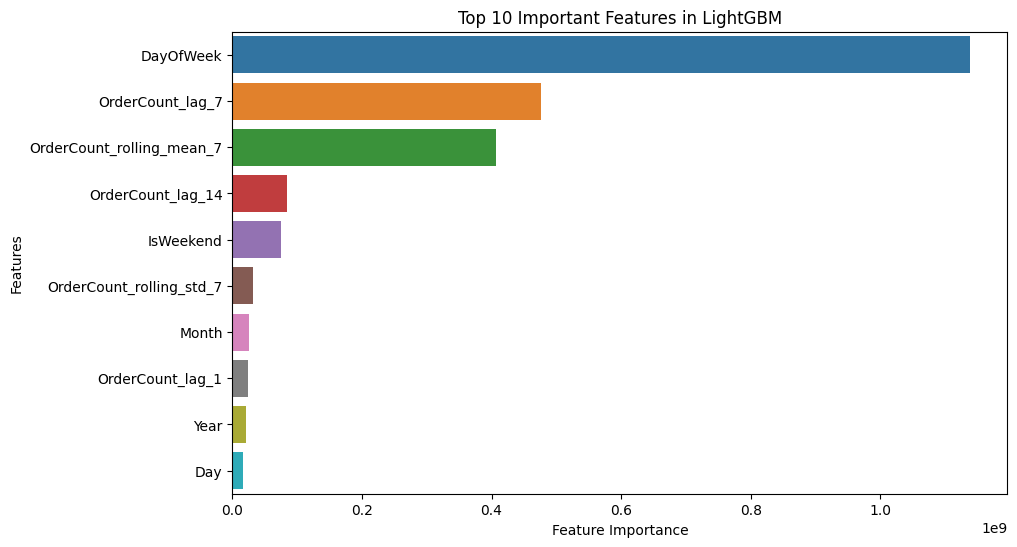

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x="Importance", y="Feature", hue="Feature", legend=False)
plt.title("Top 10 Important Features in LightGBM")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

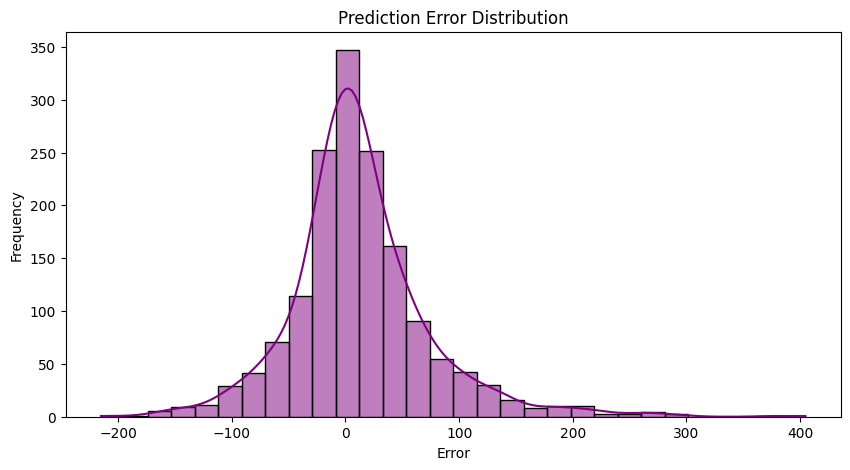

In [12]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color="purple")
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

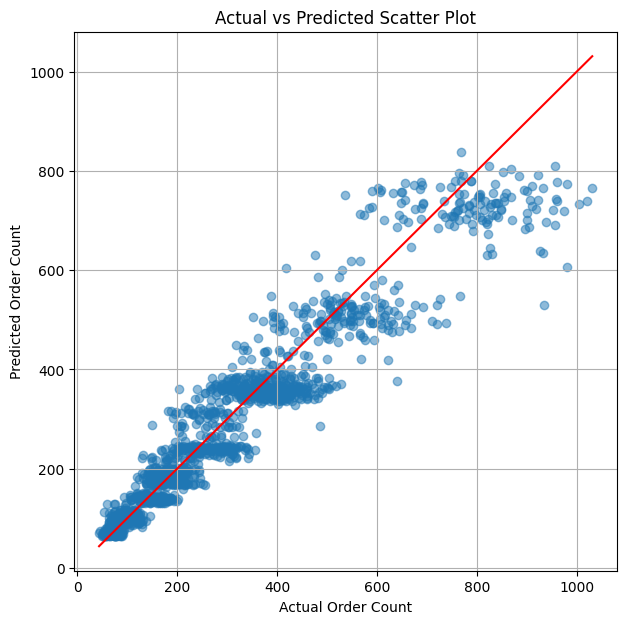

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Order Count")
plt.ylabel("Predicted Order Count")
plt.title("Actual vs Predicted Scatter Plot")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.grid()
plt.show()

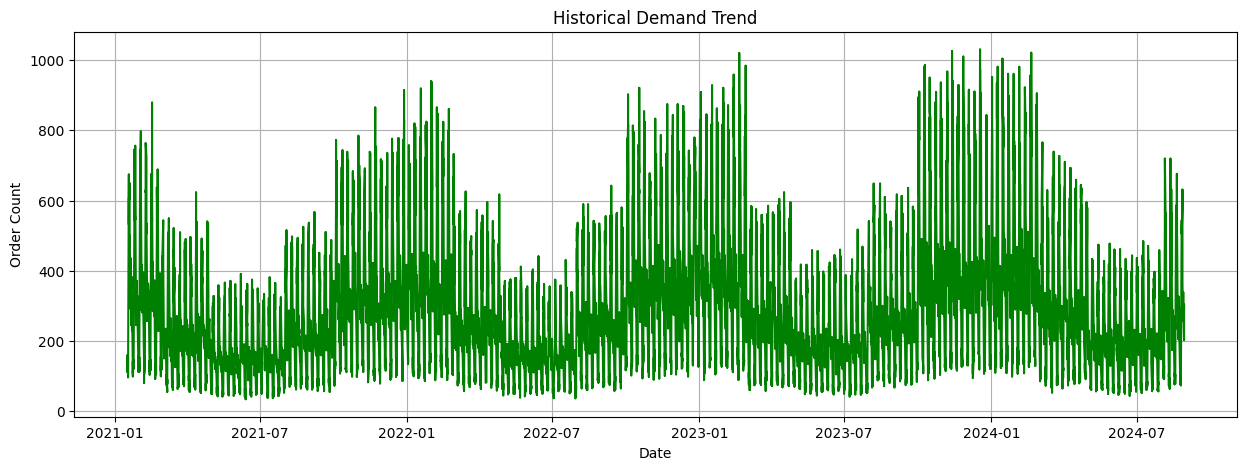

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['OrderCount'], color="green")
plt.title("Historical Demand Trend")
plt.xlabel("Date")
plt.ylabel("Order Count")
plt.grid()
plt.show()

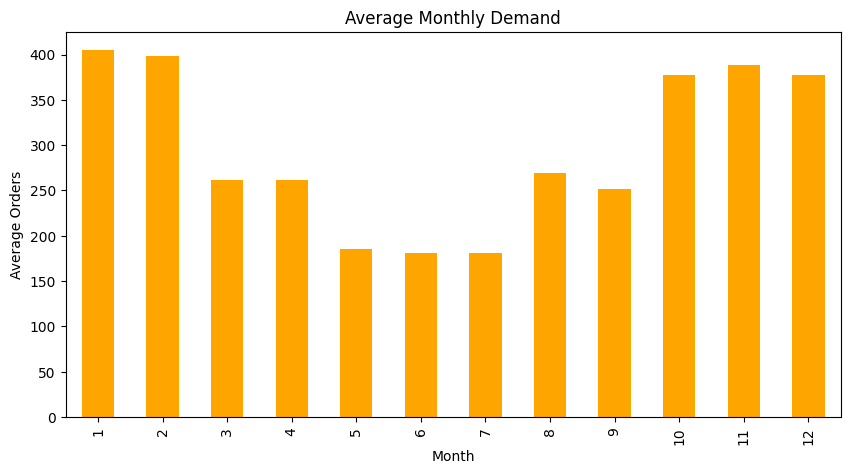

In [15]:
monthly = df.groupby('Month')['OrderCount'].mean()

plt.figure(figsize=(10, 5))
monthly.plot(kind='bar', color="orange")
plt.title("Average Monthly Demand")
plt.xlabel("Month")
plt.ylabel("Average Orders")
plt.show()

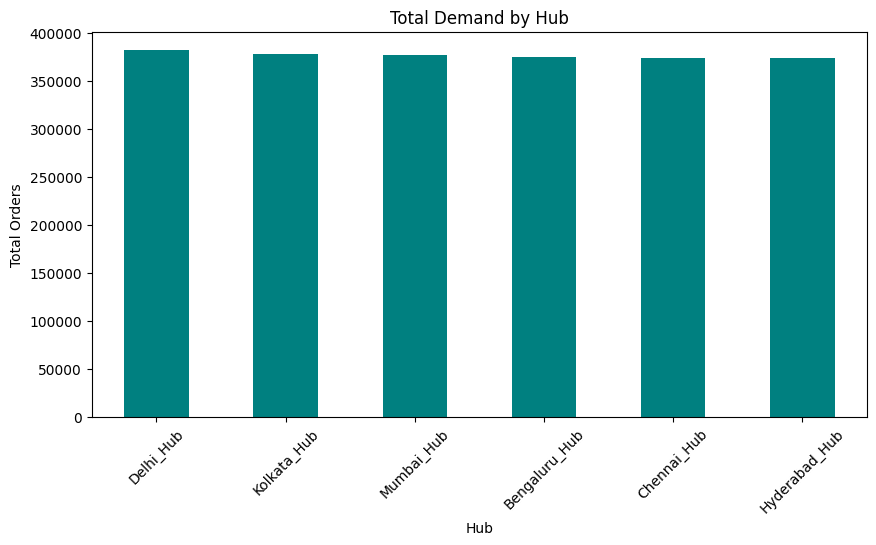

In [16]:
hub_demand = (
    df.groupby('Hub', observed=True)['OrderCount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
hub_demand.plot(kind='bar', color="teal")
plt.title("Total Demand by Hub")
plt.xlabel("Hub")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()